This notebook is a practice on the last 2 videos of the PyTorch for Deeplearning certificate: Course 1 - Module 2 - Videos 7 and 8

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim

#the computer vision and image recognition library in pytorch
import torchvision

#import the dataloader class
from torch.utils.data import DataLoader

#import the transforms module
from torchvision.transforms import transforms

In [73]:
#check gpu acceleration availability for device , default to cpu when not available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
#STEP 1,2 : Data Ingestion and Preparation-----------------------------------------------------------------
#define the transforms pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,), # mean
        (0.3081,)) # std
])

#download the MNIST training and test sets from PyTorch , apply transforms

#training set
training_data = torchvision.datasets.MNIST(
    root='./../../data', download=True , train=True , transform=transform
)

#test set
test_data = torchvision.datasets.MNIST(
    root='./../../data', download=True , train=False , transform=transform
)

- only shuffle on training data

- test batch size is usually bigger because testing computational cost is usually lower than training

In [75]:
#Load data into dataloaders
train_loader = DataLoader(training_data , batch_size=64 , shuffle=True)
test_loader = DataLoader(test_data , batch_size=1000 , shuffle=False)

- C H W = Channels , Hight , Width
- We flatten the input image to avoid input mistmatch error when the image tensor is fed to the Linear Layer
- batch before flattening: [64 , 1 , 28 , 28] -> after : [64 , 784]


In [76]:
#STEP 3: Model Buidling-------------------------------------------------------------------------------------------
#define the model
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() #to flatten images into a 1D tensor before feeding them to the model
        
        self.layers = nn.Sequential(
            #         C   W    H    128 features
            nn.Linear(1 * 28 * 28 , 128),
                
            nn.ReLU(),
            #               10 output classes or features (0 -> 9)
            nn.Linear(128 , 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

In [94]:
#create an instance of the model , move the model to device
model = MNISTClassifier().to(device)
print(model)

MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [97]:
#STEP 4: Model Training-------------------------------------------------------------------------------------------------------------------------

#define loss function
loss_function = nn.CrossEntropyLoss()  #for multiclassfication

#define optimizer
optimizer = optim.Adam(model.parameters() , lr=0.001)

#how many time are we training the model ?
epochs = 10

#define the training logic for a single epoch
def training_epoch(model , loss_function , optimizer , train_loader , device):
    model.train() #set the model to training mode
    
    running_loss = 0
    total_correct_predictions = 0
    total_samples = 0

    #loop through batches:
    for batch_idx , (inputs , targets) in enumerate(train_loader):
        #move inputs and tragets to device
        inputs , targets = inputs.to(device) , targets.to(device)

        #clear cumulated gradients from previous batch
        optimizer.zero_grad()

        #make predictions
        outputs = model(inputs)

        #calculate batch loss
        loss = loss_function(outputs , targets)

        #backpropagate from loss to calculate gradients
        loss.backward()

        #adjust weights based on gradients
        optimizer.step()

        #track progress
        running_loss += loss.item()
        _ , predicted = outputs.max(1) #finds (idx , highest logit value) in dim 1 (columns) -> what class is predicted ?
        total_correct_predictions += predicted.eq(targets).sum().item()
        total_samples += targets.size(0) #the size of targets (number of rows)


        #print progress every 100 batches
        batch_count = batch_idx + 1
        if batch_count % 100 == 0 or batch_count == len(train_loader):
            avg_loss = running_loss / batch_count
            accuracy = 100 * total_correct_predictions / total_samples
            print(f'Batches {batch_count}/{len(train_loader)} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%')

In [98]:
#STEP 5 : Model Evaluation --------------------------------------------------------------------------------------------------------------------

def evaluation_epoch(model , loss_function , test_loader , device):
    model.eval() #set model to evaluation mode

    total_correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad(): #disable PyTorch gradients for evaluation and faster computation
        for batch_idx , (inputs , targets) in enumerate(test_loader):

            #move inputs and targets to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            #make predictions
            outputs = model(inputs)

            #calculate loss
            loss = loss_function(outputs , targets)

            #track progress
            _ , predicted = outputs.max(1)
            total_correct_predictions += predicted.eq(targets).sum().item()
            total_samples += targets.size(0)

            
        accuracy = 100 * total_correct_predictions/total_samples
        print(f'Accuracy: {accuracy:.2f}%')

In [99]:
#run the train and test loops
for epoch in range(epochs):
    print(f'Epoch {epoch+1}:')
    print('Training' , '=' * 100)
    training_epoch(model , loss_function , optimizer , train_loader , device)
    print('Test' , '=' * 100)
    evaluation_epoch(model , loss_function , test_loader , device)
    

Epoch 1:
Training ====================================================================================================
Batches 100/938 | Loss: 0.6239 | Accuracy: 82.16%
Batches 200/938 | Loss: 0.4763 | Accuracy: 86.12%
Batches 300/938 | Loss: 0.4074 | Accuracy: 88.10%
Batches 400/938 | Loss: 0.3627 | Accuracy: 89.34%
Batches 500/938 | Loss: 0.3314 | Accuracy: 90.32%
Batches 600/938 | Loss: 0.3052 | Accuracy: 91.06%
Batches 700/938 | Loss: 0.2871 | Accuracy: 91.61%
Batches 800/938 | Loss: 0.2725 | Accuracy: 92.06%
Batches 900/938 | Loss: 0.2587 | Accuracy: 92.46%
Batches 938/938 | Loss: 0.2544 | Accuracy: 92.58%
Test ====================================================================================================
Accuracy: 95.47%
Epoch 2:
Training ====================================================================================================
Batches 100/938 | Loss: 0.1183 | Accuracy: 96.61%
Batches 200/938 | Loss: 0.1165 | Accuracy: 96.59%
Batches 300/938 | Loss: 0.1146 | Accura

Sample Index:   1
Predicted Digit: 2
True Label:      2


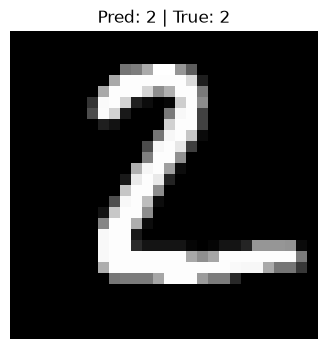

In [135]:
import matplotlib.pyplot as plt


def predict_and_visualize(model, dataset, index=0, device="cpu"):
    model.eval()  # Set model to evaluation mode

    # 1. Grab a single sample (image tensor and true label)
    image, true_label = dataset[index]

    # 2. Add batch dimension -> shape becomes [1, 1, 28, 28]
    input_tensor = image.unsqueeze(0).to(device)

    # 3. Perform inference
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = outputs.max(1)

    predicted_class = predicted.item()

    # 4. Print results
    print(f"Sample Index:   {index}")
    print(f"Predicted Digit: {predicted_class}")
    print(f"True Label:      {true_label}")

    # 5. Visualize image
    plt.figure(figsize=(4, 4))
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Pred: {predicted_class} | True: {true_label}")
    plt.axis("off")
    plt.show()


# Run prediction and plot for the 1st sample of test_data
predict_and_visualize(model, test_data, index=1, device=device)